# `baseGrid` - The geospatial groundtruth of the cubing engine

In this tutorial we will explore the functionality contained with the top most layer of the software architecture hierarchy of the `bmc` library. `baseGrid` serves as the foundation of all geospatial processing as it contains the groundtruth to which all transformations, mappings and sampling will be performed to. The class serves as the parent class for both the `rasterEngine` and `vectorEngine` leading to a further specialization of processing geospatial data. A UML diagram of the top layer is displayed below

```mermaid
classDiagram
    %% Core Foundational Class
    class baseGrid {
        +dict GRID_REGISTRY
        +resolve_grid_registry_key(target_grid, target_resolution, logger)
        +build_safe_fetch_envelope(target_grid_name, target_bounds, source_crs_or_grid, source_resolution, pixel_buffer, logger)
        +create_aligned_raster_template(sample_bbox, grid_name)
        +calculate_deterministic_global_indices(x_coords, y_coords, grid_name, logger)
    }

    %% Raster Transformation Engine
    class rasterEngine {
        +dict GDAL_RESAMPLERS
        +dict RESAMPLER_DECODER
        -_parse_res_to_meters(res_str)
        -_resolve_query_resolution(strategy, available_res, logger)
        -_sanitize_spatial_geometry(ds, default_crs, logger)
        +affine_reproject(input_data, output_filepath, grid_name, resample_keyword, compress_mode, memory_limit_bytes, num_threads, logger)
        +compute_class_fraction(source_data, class_value, grid_name, output_filepath, logger)
    }

    %% Vector Transformation Engine
    class vectorEngine {
        +coordinate_to_geometry(df, x_col, y_col, uncert_col, output_type, input_crs, on_missing_uncertainty, quad_segs, point_cloud_config, logger)
        +sanitize_geometries(gdf, allowed_types, force_multi, deduplicate, make_valid_method, logger)
        -_validate_geom_column(gdf, geom_column, allowed_types, context)
        -_build_target_grid(target_grid_name, source_crs, source_bounds, target_bbox, logger)
        -_ensure_crs(gdf, target_crs, logger)
        +generate_spatial_point_clouds(gdf, n_passes, uncertainty_col, output_col, distribution, random_state, logger)
        -_compute_home_cell_mapping(reference_geom, uid_values, uid_col_name, tree, grid_idx_values, res, output_col_name)
        +map_points_to_template(source_gdf, target_grid_name, geom_column, output_col, method, target_bbox, logger)
        +map_point_cloud_to_template(source_gdf, target_grid_name, geom_column, output_col, mode, classify_method, fraction_col, target_bbox, logger)
        +map_polygon_to_template(source_gdf, target_grid_name, geom_column, output_col, target_bbox, min_areal_fraction, include_centroid_tracking, logger)
        +map_cellCollection_to_template(source_gdf, target_grid_name, target_bbox, logger)
        +validate_vector_transformation(orig_gdf, targ_gdf, recipe, dataset_name, logger)
    }

    %% Inheritance Relationships
    baseGrid <|-- rasterEngine : Inherits
    baseGrid <|-- vectorEngine : Inherits

`baseGrid` contains functionality that relates to 

1) Definition of the master geospatial grids
2) Linking data to the master grid
3) Construction of safe and complete sampling boxes 

All these aspects will be explored in this tutorial and illustrated 

In [16]:
import numpy as np
import pandas as pd
from bmc.engine.base import baseGrid
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pyproj import Transformer

## Grid definition and usage

### Mastergrids and the `GRID_REGISTRY`

Before doing any spatial processing, the engine needs to know the exact mathematical bounds of the target space. The `baseGrid` contains a built-in GRID_REGISTRY — a dictionary defining strict coordinate reference systems (CRS) and bounding boxes to ensure flawless pixel-to-pixel alignment across distinct datasets.

In [11]:
grid = baseGrid()

print("Available Master Grids:")
# The GRID_REGISTRY acts as the master dictionary of supported target projection frameworks
for grid_key, grid_info in grid.GRID_REGISTRY.items():
    print(f" - {grid_key}: {grid_info['crs']} | Res: {grid_info['resolution']}")

Available Master Grids:
 - EEA_10m: EPSG:3035 | Res: 10
 - EEA_100m: EPSG:3035 | Res: 100
 - EEA_250m: EPSG:3035 | Res: 250
 - EEA_500m: EPSG:3035 | Res: 500
 - EEA_1km: EPSG:3035 | Res: 1000
 - EEA_10km: EPSG:3035 | Res: 10000
 - Global_EqualArea_10m: EPSG:6933 | Res: 10
 - Global_EqualArea_100m: EPSG:6933 | Res: 100
 - Global_EqualArea_250m: EPSG:6933 | Res: 250
 - Global_EqualArea_500m: EPSG:6933 | Res: 500
 - Global_EqualArea_1km: EPSG:6933 | Res: 1000
 - Global_EqualArea_10km: EPSG:6933 | Res: 10000
 - Global_WGS84_0_3sec: EPSG:4326 | Res: 8.333333333333333e-05
 - Global_WGS84_3sec: EPSG:4326 | Res: 0.0008333333333333333
 - Global_WGS84_7_5sec: EPSG:4326 | Res: 0.0020833333333333333
 - Global_WGS84_15sec: EPSG:4326 | Res: 0.004166666666666667
 - Global_WGS84_30sec: EPSG:4326 | Res: 0.008333333333333333
 - Global_WGS84_5min: EPSG:4326 | Res: 0.08333333333333333


![Visualisation of the master grids available in the BMC soatiotemporal_cube base class](img/grid_extents.png)

By defining a finite set of grids we can precisely control and assure that data is mapped seamlessly making harmonization easy to implement. We define the grid resolution in

1) Multiples of 10 (or the equivalent). Base 10 is chosen due to the fact that most datasource employ these resolutions
2) Divisors of multiples starting from 1000, 250 and 500 are both divisors of 1000 and 10000 respectively

Defining the grids in this fashion imparts an additional benefit, namely by imposing this criterion on resolutiosn we assure that grids of different resolutions can be laid on top of each other 1-to-1 (without introducing topological shifts). This allows us to generate slices that will always be describing the same area, i.e. the same bounds, but at different levels of details.

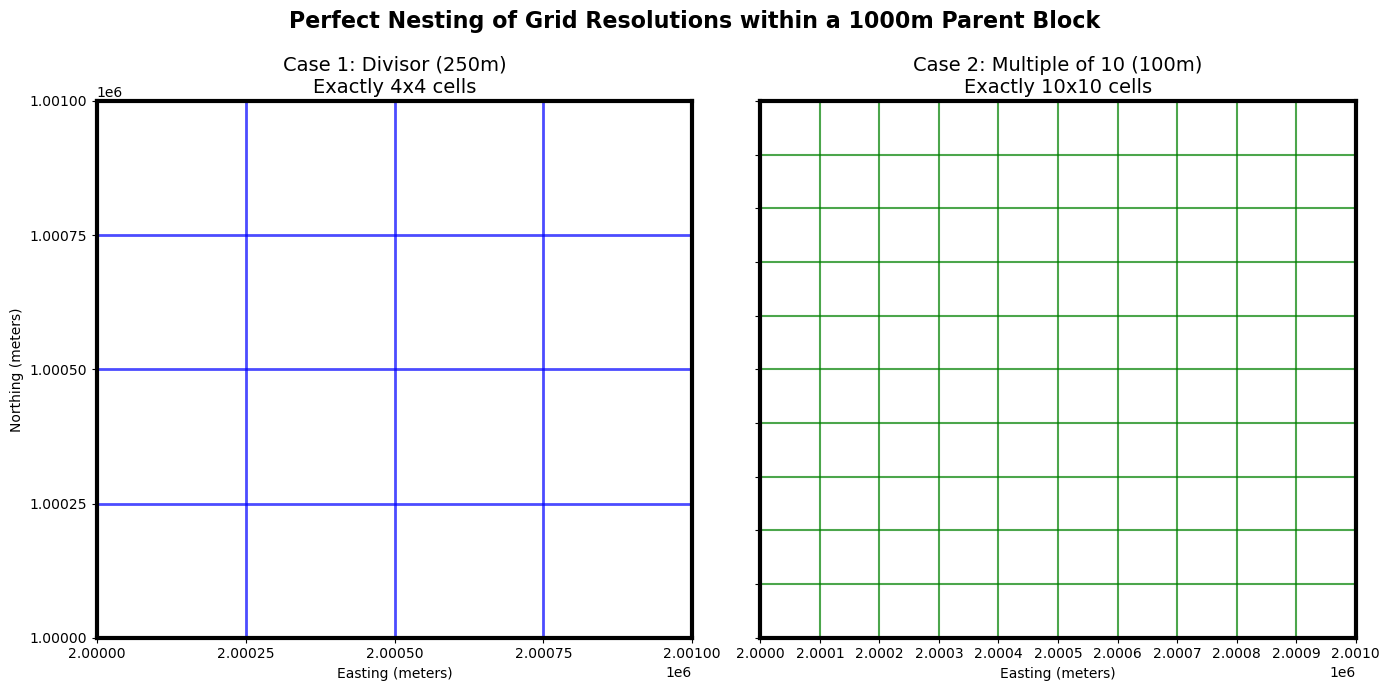

In [5]:
# Define a single 1000m x 1000m block using the EEA absolute origin
# from base.py to guarantee mathematical alignment.
master_minx = 2000000
master_miny = 1000000
master_maxx = master_minx + 1000
master_maxy = master_miny + 1000

# Initialize the visualization figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle("Perfect Nesting of Grid Resolutions within a 1000m Parent Block", fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# Case 1: Divisor (250m resolution inside a 1000m block)
# ---------------------------------------------------------
ax1.set_xlim(master_minx, master_maxx)
ax1.set_ylim(master_miny, master_maxy)

# Generate ticks strictly at 250m intervals
ax1.set_xticks(range(master_minx, master_maxx + 1, 250))
ax1.set_yticks(range(master_miny, master_maxy + 1, 250))

# Draw the grid
ax1.grid(color='blue', linestyle='-', linewidth=2, alpha=0.7)
ax1.set_title("Case 1: Divisor (250m)\nExactly 4x4 cells", fontsize=14)
ax1.set_xlabel("Easting (meters)")
ax1.set_ylabel("Northing (meters)")

# ---------------------------------------------------------
# Case 2: Multiple of 10 (100m resolution inside a 1000m block)
# ---------------------------------------------------------
ax2.set_xlim(master_minx, master_maxx)
ax2.set_ylim(master_miny, master_maxy)

# Generate ticks strictly at 100m intervals
ax2.set_xticks(range(master_minx, master_maxx + 1, 100))
ax2.set_yticks(range(master_miny, master_maxy + 1, 100))

# Draw the grid
ax2.grid(color='green', linestyle='-', linewidth=1.5, alpha=0.7)
ax2.set_title("Case 2: Multiple of 10 (100m)\nExactly 10x10 cells", fontsize=14)
ax2.set_xlabel("Easting (meters)")

# Hide the y-axis labels on the second plot for cleaner visuals
ax2.tick_params(labelleft=False) 

# Add a bold border to both plots to represent the 1000m parent boundary
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_color('black')

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

## Grid sampling 

When querying raw remote data (like a global WGS84 dataset) to fit a specific target grid (like a metric European EPSG:3035 projection), we cannot simply transform the four corners of our bounding box.

1) Projection Curvature: Due to the Earth's curvature, the edges of a reprojected bounding box bow outward. If we only transform the 4 corners, we will miss data along these curves.

2) Edge Starvation: Multi-pixel GDAL resampling algorithms (like cubic or average) require surrounding "neighbor" pixels to calculate the final values at the very edge of your region. Without a buffer, the boundary pixels turn into NaNs.

The ``build_safe_fetch_envelope`` solves this by densifying the perimeter using vectorized linear interpolation to capture the true curvature, and then buffers the bounding box outward by a set number of native source pixels. 

1. Naive Bounding Box (EPSG:4326):
   (5.5178, 50.0241, 6.8528, 50.9686)

Computing safe fetch envelope for target grid 'EEA_1km'...
Safe Source Envelope (EPSG:4326): (5.38995, 49.98245, 6.95396, 51.01023)
2. Safe Densified & Buffered Envelope (EPSG:4326):
   (5.3899, 49.9825, 6.9540, 51.0102)

3. Why it matters:
   The safe envelope expanded the X-axis by 0.2290 degrees
   The safe envelope expanded the Y-axis by 0.0833 degrees
   This prevents NaN edge artifacts when the C++ GDAL kernel runs.


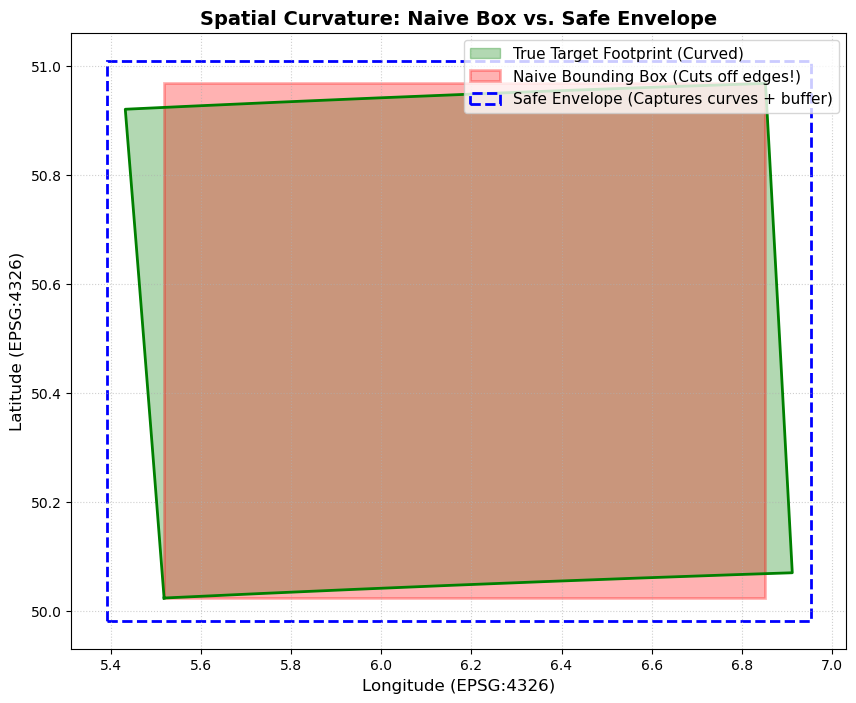

In [15]:
target_grid = "EEA_1km"
study_area_bounds = (4000000, 3000000, 4100000, 3100000) # (minx, miny, maxx, maxy)

# --- 1. Naive Approach (Transforming just the 4 corners) ---
transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
naive_minx, naive_miny = transformer.transform(study_area_bounds[0], study_area_bounds[1])
naive_maxx, naive_maxy = transformer.transform(study_area_bounds[2], study_area_bounds[3])

print("1. Naive Bounding Box (EPSG:4326):")
print(f"   ({naive_minx:.4f}, {naive_miny:.4f}, {naive_maxx:.4f}, {naive_maxy:.4f})\n")

# --- 2. Safe Engine Approach ---
# We ask the engine to buffer the envelope by 5 pixels based on a 30 arc-second WGS84 source
safe_bounds = grid.build_safe_fetch_envelope(
    target_grid_name=target_grid,
    target_bounds=study_area_bounds,
    source_crs_or_grid="Global_WGS84_30sec",
    pixel_buffer=5 
)

print("2. Safe Densified & Buffered Envelope (EPSG:4326):")
print(f"   ({safe_bounds[0]:.4f}, {safe_bounds[1]:.4f}, {safe_bounds[2]:.4f}, {safe_bounds[3]:.4f})\n")

# --- 3. The Mathematical Difference ---
x_expansion = (naive_minx - safe_bounds[0]) + (safe_bounds[2] - naive_maxx)
y_expansion = (naive_miny - safe_bounds[1]) + (safe_bounds[3] - naive_maxy)

print("3. Why it matters:")
print(f"   The safe envelope expanded the X-axis by {x_expansion:.4f} degrees")
print(f"   The safe envelope expanded the Y-axis by {y_expansion:.4f} degrees")
print("   This prevents NaN edge artifacts when the C++ GDAL kernel runs.")

# --- 1. Recreate the Densified Target Perimeter ---
minx, miny, maxx, maxy = study_area_bounds
num_points = 100 

# Create the 4 edges with 100 points each
bx = np.linspace(minx, maxx, num_points); by = np.full(num_points, miny)
rx = np.full(num_points, maxx); ry = np.linspace(miny, maxy, num_points)
tx = np.linspace(maxx, minx, num_points); ty = np.full(num_points, maxy)
lx = np.full(num_points, minx); ly = np.linspace(maxy, miny, num_points)

perimeter_x = np.concatenate([bx, rx, tx, lx])
perimeter_y = np.concatenate([by, ry, ty, ly])

# Transform the dense perimeter to WGS84
transformer = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True)
true_src_x, true_src_y = transformer.transform(perimeter_x, perimeter_y)

# --- 2. Plotting the Geometries ---
fig, ax = plt.subplots(figsize=(10, 8))

# A. Plot the True Target Footprint (The curved shape)
ax.fill(true_src_x, true_src_y, alpha=0.3, color='green', label='True Target Footprint (Curved)')
ax.plot(true_src_x, true_src_y, color='green', linewidth=2)

# B. Plot the Naive Bounding Box (Red, with transparent fill)
naive_rect = patches.Rectangle(
    (naive_minx, naive_miny), 
    naive_maxx - naive_minx, naive_maxy - naive_miny,
    linewidth=2, edgecolor='red', facecolor='red', alpha=0.3, label='Naive Bounding Box (Cuts off edges!)'
)
ax.add_patch(naive_rect)

# C. Plot the Safe Envelope (Blue, Dashed)
safe_rect = patches.Rectangle(
    (safe_bounds[0], safe_bounds[1]), 
    safe_bounds[2] - safe_bounds[0], safe_bounds[3] - safe_bounds[1],
    linewidth=2, edgecolor='blue', linestyle='--', facecolor='none', label='Safe Envelope (Captures curves + buffer)'
)
ax.add_patch(safe_rect)

# Formatting the plot
ax.set_aspect('auto')
plt.title("Spatial Curvature: Naive Box vs. Safe Envelope", fontsize=14, fontweight='bold')
plt.xlabel("Longitude (EPSG:4326)", fontsize=12)
plt.ylabel("Latitude (EPSG:4326)", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

Inspecting the comparison reveals the benefit of the fetching envelope. the two boxes don't overlap perfectly which results in section that will have no data. Utilizing the safe envelope we see that both boxes are encompassed and we can mask either both of them without any data loss happening.

## Grid indexation

## Deterministic Global Grid Indexation

When working with large spatiotemporal datasets, joining and grouping continuous spatial data via geographic intersections (like points-in-polygons) is computationally expensive. To solve this, the spatial pipeline uses **Global Grid Indexation**. 

Instead of relying on slow spatial operations, the `base_spatial_grid` engine converts local 2D geographic coordinates (X and Y) into a single, deterministic 1D integer index. 

Because all resolutions within a master grid share a rigid absolute bounding box and origin, this 1D index is globally consistent. If you have two completely different datasets containing points that fall within the exact same 1km grid cell, they will automatically be assigned the exact same `global_grid_id`.

### The Mathematics of the Index
The engine calculates this ID by determining how many total columns exist across the entire master grid[cite: 1]. It then calculates the absolute column and row offset of your specific coordinates relative to the top-left origin. Finally, it flattens this 2D matrix location into a 1D index using this formula:

$$ \text{global\_grid\_id} = (\text{global\_row} \times \text{total\_global\_cols}) + \text{global\_col} $$

In [17]:
# 1. Define the target master grid
# We will use the 10km EEA reference grid for this example
target_grid = "EEA_10km"

# 2. Simulate local 2D coordinates
# Imagine we have 4 points (e.g., weather stations or sensor readings) 
# located somewhere in Europe, projected in EPSG:3035.
x_coords = np.array([4005000, 4015000, 4005000, 4500000])
y_coords = np.array([3005000, 3005000, 2995000, 3500000])

# 3. Calculate the deterministic global IDs
global_ids = grid.calculate_deterministic_global_indices(
    x_coords=x_coords,
    y_coords=y_coords,
    grid_name=target_grid
)

# 4. Display the mapping
# Let's put this into a DataFrame so we can easily visualize how 
# the 2D spatial coordinates map to the 1D global identifiers.
df_mapping = pd.DataFrame({
    "Point_ID": ["Sensor_A", "Sensor_B", "Sensor_C", "Sensor_D"],
    "X_Coord (Easting)": x_coords,
    "Y_Coord (Northing)": y_coords,
    "Global_Grid_ID": global_ids
})

print(f"Master Grid Selected: {target_grid}")
print("-" * 50)
print(df_mapping.to_string(index=False))

Master Grid Selected: EEA_10km
--------------------------------------------------
Point_ID  X_Coord (Easting)  Y_Coord (Northing)  Global_Grid_ID
Sensor_A            4005000             3005000           99800
Sensor_B            4015000             3005000           99801
Sensor_C            4005000             2995000          100200
Sensor_D            4500000             3500000           80250
